In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
df = pd.read_csv("traffic_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (991464, 5)


,step,vehicle_id,speed,waiting_time,co2_emission
0,0,0,0.000000,0.0,1521.000000
1,1,0,2.029624,0.0,3538.964350
2,2,0,3.984050,0.0,4087.459401
3,2,1,0.000000,0.0,1521.000000
4,3,0,6.542953,0.0,6029.885257


In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991464 entries, 0 to 991463
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   step          991464 non-null  int64  
 1   vehicle_id    991464 non-null  int64  
 2   speed         991464 non-null  float64
 3   waiting_time  991464 non-null  float64
 4   co2_emission  991464 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 37.8 MB


,step,vehicle_id,speed,waiting_time,co2_emission
count,991464.000000,991464.000000,991464.000000,991464.000000,991464.000000
mean,2194.232553,1184.240175,4.001624,33.608347,2193.808084
std,958.528148,587.030690,6.400946,62.332181,2324.819493
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1440.000000,733.000000,0.000000,0.000000,1521.000000
50%,2351.000000,1223.000000,0.000000,6.000000,1521.000000
75%,3017.000000,1645.000000,7.441069,40.000000,1650.808261
max,3599.000000,2399.000000,36.360966,822.000000,31406.083165


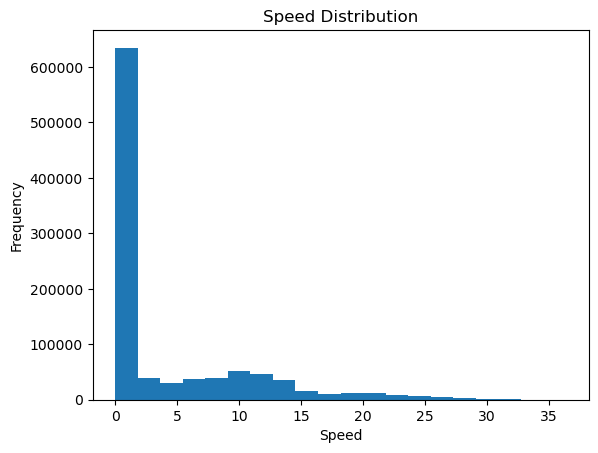

In [14]:
plt.figure()
plt.hist(df["speed"], bins=20)
plt.title("Speed Distribution")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()

In [15]:
df["congestion"] = (df["speed"] < 2).astype(int)

df.head()

,step,vehicle_id,speed,waiting_time,co2_emission,congestion
0,0,0,0.000000,0.0,1521.000000,1
1,1,0,2.029624,0.0,3538.964350,0
2,2,0,3.984050,0.0,4087.459401,0
3,2,1,0.000000,0.0,1521.000000,1
4,3,0,6.542953,0.0,6029.885257,0


In [17]:
df_grouped = df.groupby("step").agg({
    "speed": "mean",
    "co2_emission": "mean",
    "vehicle_id": "count",
    "congestion": "sum"
}).rename(columns={"vehicle_id": "vehicle_count"})

# Final congestion per step
df_grouped["congestion"] = (df_grouped["congestion"] > 1).astype(int)

df_grouped.head()

,speed,co2_emission,vehicle_count,congestion
step,,,,
0,0.000000,1521.000000,1,0
1,2.029624,3538.964350,1,0
2,1.992025,2804.229701,2,0
3,2.777435,3596.051882,3,1
4,4.682152,4257.373844,3,0


In [18]:
X = df_grouped[["speed", "co2_emission", "vehicle_count"]]
y = df_grouped["congestion"]

print(X.head())
print(y.head())

         speed  co2_emission  vehicle_count
step                                       
0     0.000000   1521.000000              1
1     2.029624   3538.964350              1
2     1.992025   2804.229701              2
3     2.777435   3596.051882              3
4     4.682152   4257.373844              3
step
0    0
1    0
2    0
3    1
4    0
Name: congestion, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = model.predict(X_test)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9958333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       1.00      1.00      1.00       716

    accuracy                           1.00       720
   macro avg       1.00      0.62      0.70       720
weighted avg       1.00      1.00      0.99       720



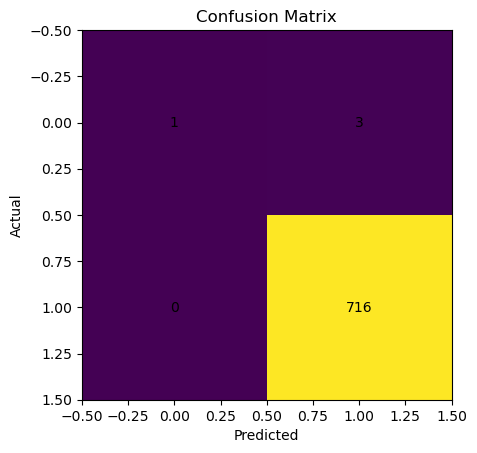

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

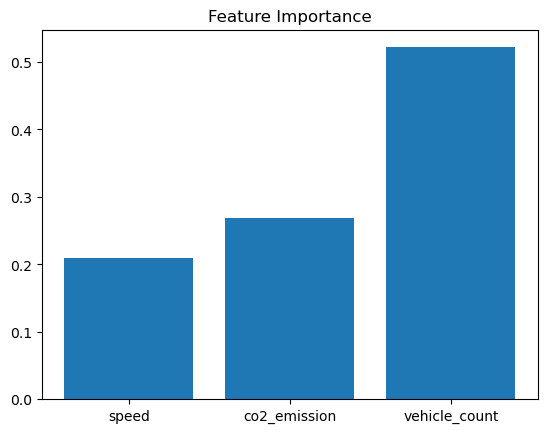

In [25]:
importances = model.feature_importances_

plt.figure()
plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [26]:
def predict_congestion(speed, co2, vehicle_count):
    data = [[speed, co2, vehicle_count]]
    return model.predict(data)[0]